# Phase 2 — A/B Testing and Average Incrementality

## TL;DR

- The analysis uses randomized `treatment`, not observed `exposure`, so the primary estimates preserve the experiment's causal comparison.
- Enabling advertising increased the visit rate from **3.8201%** to **4.8543%**, an absolute lift of **1.0342 percentage points** and a relative lift of **27.07%**.
- Enabling advertising increased the conversion rate from **0.1938%** to **0.3089%**, an absolute lift of **0.1152 percentage points** and a relative lift of **59.45%**.
- At the observed treatment-arm size, the estimates correspond to approximately **122,895 incremental visits** and **13,687 incremental conversions**.
- Both outcomes are statistically significant after Holm adjustment. Conversion remains less precisely estimated than visit because it is much rarer.
- The initial 10,000-replicate bootstrap triggered the prespecified stability escalation, so the final reported bootstrap intervals use **50,000 deterministic replicates**.

These results describe average effects in the released, anonymized, subsampled experimental dataset. They are not the original incrementality estimates of a named advertiser or campaign.

## 1. Context and Analysis Plan

### Phase objective

Phase 2 estimates the average causal effect of enabling Criteo advertising on:

1. website visits; and
2. advertiser-defined conversions.

This phase answers whether advertising works **on average**. It does not yet answer which users should be targeted; heterogeneous treatment effects begin in Phase 3.

### Experiment charter

| Decision | Selected specification |
|---|---|
| Population | All rows retained after Phase 1 quality review |
| Treatment | Randomized `treatment` assignment |
| Outcomes | `visit` and `conversion`, analyzed separately |
| Effect measures | Absolute lift (ATE), relative lift, incremental outcomes |
| Confidence level | 95% |
| Hypothesis test | Two-sided two-sample z-test for proportions |
| Significance level | 0.05 |
| Multiplicity | Raw and Holm-adjusted p-values across the two outcomes |
| Bootstrap | Treatment-stratified binary-outcome bootstrap with a frozen seed |

### Key assumptions and interpretation boundaries

- Randomized assignment occurred at the `treatment` level. Observed `exposure` is post-assignment and is not used to define the primary causal groups.
- Exact duplicate-looking rows are retained because the released data lack user and event identifiers; Phase 1 established that deleting them would not be defensible.
- The analysis estimates effects in the full released sample. The train/validation/test partition created for Phase 3 modeling is not used here.
- An exposed-versus-unexposed contrast is observational because auction eligibility and Criteo's bidding system influence actual exposure.
- Campaign, time, cost, and revenue fields are absent, so campaign-level heterogeneity, seasonality, ROI, and profit cannot be estimated.

## 2. Setup and Reproducibility

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.stats import norm


def find_project_root(start_path: Path) -> Path:
    """Find the project root containing the data and src folders."""
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "data").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
PARQUET_PATH = PROJECT_ROOT / "data" / "processed" / "criteo-uplift-v2.1.parquet"
FIGURE_DIRECTORY = PROJECT_ROOT / "reports" / "figures" / "phase2"
TABLE_DIRECTORY = PROJECT_ROOT / "reports" / "tables"

EXPECTED_ROW_COUNT = 13_979_592
CONFIDENCE_LEVEL = 0.95
ALPHA = 0.05
Z_CRITICAL = 1.96
BOOTSTRAP_SEED = 20_260_809
INITIAL_BOOTSTRAP_REPLICATES = 10_000
ESCALATED_BOOTSTRAP_REPLICATES = 50_000

FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)
TABLE_DIRECTORY.mkdir(parents=True, exist_ok=True)

if not PARQUET_PATH.exists():
    raise FileNotFoundError(f"Analysis-ready Parquet file not found: {PARQUET_PATH}")

PARQUET_SQL_PATH = str(PARQUET_PATH).replace("'", "''")
connection = duckdb.connect()

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#667085",
        "axes.labelcolor": "#344054",
        "text.color": "#101828",
        "xtick.color": "#475467",
        "ytick.color": "#475467",
        "font.size": 10,
    }
)

CONTROL_COLOR = "#98A2B3"
TREATMENT_COLOR = "#1F5A94"
REFERENCE_COLOR = "#475467"
SECONDARY_COLOR = "#D97706"

print(f"Project root: {PROJECT_ROOT}")
print(f"Input dataset: {PARQUET_PATH}")
print(f"Bootstrap seed: {BOOTSTRAP_SEED:,}")

Project root: /Users/ever/Library/CloudStorage/OneDrive2-ColumbiaUniversityIrvingMedicalCenter/adlift项目
Input dataset: /Users/ever/Library/CloudStorage/OneDrive2-ColumbiaUniversityIrvingMedicalCenter/adlift项目/data/processed/criteo-uplift-v2.1.parquet
Bootstrap seed: 20,260,809


## 3. Validate the Analysis Input

In [2]:
schema_table = connection.execute(
    f"DESCRIBE SELECT * FROM read_parquet('{PARQUET_SQL_PATH}')"
).df()

expected_columns = {
    *[f"f{i}" for i in range(12)],
    "treatment",
    "conversion",
    "visit",
    "exposure",
}

input_checks = connection.execute(
    f"""
    SELECT
        COUNT(*) AS row_count,
        COUNT_IF(treatment IS NULL OR exposure IS NULL OR visit IS NULL OR conversion IS NULL)
            AS rows_with_null_experiment_fields,
        COUNT_IF(treatment NOT IN (0, 1)) AS invalid_treatment_rows,
        COUNT_IF(exposure NOT IN (0, 1)) AS invalid_exposure_rows,
        COUNT_IF(visit NOT IN (0, 1)) AS invalid_visit_rows,
        COUNT_IF(conversion NOT IN (0, 1)) AS invalid_conversion_rows,
        COUNT_IF(treatment = 0 AND exposure = 1) AS exposed_control_rows,
        COUNT_IF(conversion = 1 AND visit = 0) AS conversion_without_visit_rows
    FROM read_parquet('{PARQUET_SQL_PATH}')
    """
).df()

observed_columns = set(schema_table["column_name"])
check_row = input_checks.iloc[0]

assert observed_columns == expected_columns
assert int(check_row["row_count"]) == EXPECTED_ROW_COUNT
assert int(check_row["rows_with_null_experiment_fields"]) == 0
assert int(check_row["invalid_treatment_rows"]) == 0
assert int(check_row["invalid_exposure_rows"]) == 0
assert int(check_row["invalid_visit_rows"]) == 0
assert int(check_row["invalid_conversion_rows"]) == 0
assert int(check_row["exposed_control_rows"]) == 0
assert int(check_row["conversion_without_visit_rows"]) == 0

display(input_checks.style.format("{:,.0f}"))
print("Input validation passed.")

,row_count,rows_with_null_experiment_fields,invalid_treatment_rows,invalid_exposure_rows,invalid_visit_rows,invalid_conversion_rows,exposed_control_rows,conversion_without_visit_rows
0,"13,979,592",0,0,0,0,0,0,0


Input validation passed.


### Validation conclusion

The full 13,979,592-row released population is used. The experiment fields are complete and binary, no control record is marked as exposed, and every recorded conversion is accompanied by a visit. These checks reconcile Phase 2 with the Phase 1 audit decisions.

## 4. Arm Counts and Outcome Rates

In [3]:
arm_summary = connection.execute(
    f"""
    SELECT
        treatment,
        COUNT(*) AS sample_size,
        SUM(exposure) AS exposure_positive,
        AVG(exposure) AS exposure_rate,
        SUM(visit) AS visit_positive,
        AVG(visit) AS visit_rate,
        SUM(conversion) AS conversion_positive,
        AVG(conversion) AS conversion_rate
    FROM read_parquet('{PARQUET_SQL_PATH}')
    GROUP BY treatment
    ORDER BY treatment
    """
).df()

assert set(arm_summary["treatment"]) == {0, 1}
assert int(arm_summary["sample_size"].sum()) == EXPECTED_ROW_COUNT

arm_summary["arm"] = arm_summary["treatment"].map({0: "Control", 1: "Treatment"})
arm_summary = arm_summary[
    [
        "arm",
        "treatment",
        "sample_size",
        "exposure_positive",
        "exposure_rate",
        "visit_positive",
        "visit_rate",
        "conversion_positive",
        "conversion_rate",
    ]
]

display(
    arm_summary.style.format(
        {
            "sample_size": "{:,.0f}",
            "exposure_positive": "{:,.0f}",
            "exposure_rate": "{:.4%}",
            "visit_positive": "{:,.0f}",
            "visit_rate": "{:.4%}",
            "conversion_positive": "{:,.0f}",
            "conversion_rate": "{:.4%}",
        }
    )
)

,arm,treatment,sample_size,exposure_positive,exposure_rate,visit_positive,visit_rate,conversion_positive,conversion_rate
0,Control,0,"2,096,937",0,0.0000%,"80,105",3.8201%,"4,063",0.1938%
1,Treatment,1,"11,882,655","428,212",3.6037%,"576,824",4.8543%,"36,711",0.3089%


## 5. Effect Sizes and Analytical Confidence Intervals

For each binary outcome:

$$
\widehat{ATE}=\hat p_1-\hat p_0
$$

$$
\widehat L_{relative}=\frac{\hat p_1-\hat p_0}{\hat p_0}
$$

The analytical ATE interval uses the unpooled standard error:

$$
SE(\widehat{ATE})=
\sqrt{\frac{\hat p_1(1-\hat p_1)}{N_1}+\frac{\hat p_0(1-\hat p_0)}{N_0}}
$$

The relative-lift interval is constructed on the log-risk-ratio scale and transformed back by subtracting one from each risk-ratio endpoint.

In [4]:
def calculate_effect_row(
    outcome: str,
    control_n: int,
    treatment_n: int,
    control_positive: int,
    treatment_positive: int,
) -> dict:
    """Calculate Phase 2 effect measures and analytical intervals."""
    control_rate = control_positive / control_n
    treatment_rate = treatment_positive / treatment_n
    absolute_lift = treatment_rate - control_rate
    relative_lift = absolute_lift / control_rate

    absolute_se = np.sqrt(
        treatment_rate * (1 - treatment_rate) / treatment_n
        + control_rate * (1 - control_rate) / control_n
    )
    absolute_ci_lower = absolute_lift - Z_CRITICAL * absolute_se
    absolute_ci_upper = absolute_lift + Z_CRITICAL * absolute_se

    log_risk_ratio = np.log(treatment_rate / control_rate)
    log_risk_ratio_se = np.sqrt(
        1 / treatment_positive
        - 1 / treatment_n
        + 1 / control_positive
        - 1 / control_n
    )
    relative_ci_lower = np.exp(
        log_risk_ratio - Z_CRITICAL * log_risk_ratio_se
    ) - 1
    relative_ci_upper = np.exp(
        log_risk_ratio + Z_CRITICAL * log_risk_ratio_se
    ) - 1

    total_n = control_n + treatment_n

    return {
        "outcome": outcome,
        "control_n": control_n,
        "treatment_n": treatment_n,
        "control_positive": control_positive,
        "treatment_positive": treatment_positive,
        "control_rate": control_rate,
        "treatment_rate": treatment_rate,
        "absolute_lift": absolute_lift,
        "absolute_ci_lower": absolute_ci_lower,
        "absolute_ci_upper": absolute_ci_upper,
        "relative_lift": relative_lift,
        "relative_ci_lower": relative_ci_lower,
        "relative_ci_upper": relative_ci_upper,
        "incremental_treated": treatment_n * absolute_lift,
        "incremental_all": total_n * absolute_lift,
    }


control_row = arm_summary.loc[arm_summary["treatment"] == 0].iloc[0]
treatment_row = arm_summary.loc[arm_summary["treatment"] == 1].iloc[0]

effect_rows = []
for outcome in ["visit", "conversion"]:
    effect_rows.append(
        calculate_effect_row(
            outcome=outcome,
            control_n=int(control_row["sample_size"]),
            treatment_n=int(treatment_row["sample_size"]),
            control_positive=int(control_row[f"{outcome}_positive"]),
            treatment_positive=int(treatment_row[f"{outcome}_positive"]),
        )
    )

effect_results = pd.DataFrame(effect_rows)

assert (effect_results[["control_rate", "treatment_rate"]] > 0).all().all()
assert (effect_results[["control_rate", "treatment_rate"]] < 1).all().all()
assert (effect_results["absolute_lift"] > 0).all()

display(
    effect_results[
        [
            "outcome",
            "control_rate",
            "treatment_rate",
            "absolute_lift",
            "absolute_ci_lower",
            "absolute_ci_upper",
            "relative_lift",
            "relative_ci_lower",
            "relative_ci_upper",
            "incremental_treated",
            "incremental_all",
        ]
    ].style.format(
        {
            "control_rate": "{:.4%}",
            "treatment_rate": "{:.4%}",
            "absolute_lift": "{:.4%}",
            "absolute_ci_lower": "{:.4%}",
            "absolute_ci_upper": "{:.4%}",
            "relative_lift": "{:.2%}",
            "relative_ci_lower": "{:.2%}",
            "relative_ci_upper": "{:.2%}",
            "incremental_treated": "{:,.0f}",
            "incremental_all": "{:,.0f}",
        }
    )
)

,outcome,control_rate,treatment_rate,absolute_lift,absolute_ci_lower,absolute_ci_upper,relative_lift,relative_ci_lower,relative_ci_upper,incremental_treated,incremental_all
0,visit,3.8201%,4.8543%,1.0342%,1.0056%,1.0629%,27.07%,26.16%,28.00%,"122,895","144,583"
1,conversion,0.1938%,0.3089%,0.1152%,0.1085%,0.1219%,59.45%,54.37%,64.70%,"13,687","16,103"


## 6. Treatment-Stratified Bootstrap

For a binary outcome, resampling individual values within each randomized arm is equivalent to drawing the number of positive outcomes from the fitted arm-specific binomial distributions:

$$
Y_1^*\sim Binomial(N_1,\hat p_1),\qquad
Y_0^*\sim Binomial(N_0,\hat p_0)
$$

This implementation avoids repeatedly materializing the 13.98-million-row dataset. It uses a frozen, outcome-specific random seed and percentile intervals.

In [5]:
def run_binary_bootstrap(effect_row: pd.Series, replicates: int, seed: int) -> pd.DataFrame:
    """Run an efficient arm-stratified bootstrap for one binary outcome."""
    random_generator = np.random.default_rng(seed)

    treatment_positive = random_generator.binomial(
        int(effect_row["treatment_n"]),
        float(effect_row["treatment_rate"]),
        size=replicates,
    )
    control_positive = random_generator.binomial(
        int(effect_row["control_n"]),
        float(effect_row["control_rate"]),
        size=replicates,
    )

    treatment_rate = treatment_positive / int(effect_row["treatment_n"])
    control_rate = control_positive / int(effect_row["control_n"])
    absolute_lift = treatment_rate - control_rate

    relative_lift = np.divide(
        absolute_lift,
        control_rate,
        out=np.full(replicates, np.nan, dtype=float),
        where=control_rate > 0,
    )

    return pd.DataFrame(
        {
            "absolute_lift": absolute_lift,
            "relative_lift": relative_lift,
        }
    )


def percentile_interval(values: pd.Series) -> np.ndarray:
    """Return the 95% percentile interval after removing undefined values."""
    clean_values = values.dropna().to_numpy()
    return np.quantile(clean_values, [0.025, 0.975])


def build_bootstrap_intervals(samples_by_outcome: dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []
    for outcome, samples in samples_by_outcome.items():
        for measure in ["absolute_lift", "relative_lift"]:
            lower, upper = percentile_interval(samples[measure])
            rows.append(
                {
                    "outcome": outcome,
                    "measure": measure,
                    "bootstrap_ci_lower": lower,
                    "bootstrap_ci_upper": upper,
                    "bootstrap_interval_width": upper - lower,
                    "undefined_replicates": int(samples[measure].isna().sum()),
                }
            )
    return pd.DataFrame(rows)


initial_bootstrap_samples = {}
for outcome_index, effect_row in effect_results.set_index("outcome").iterrows():
    seed_offset = 0 if outcome_index == "visit" else 1
    initial_bootstrap_samples[outcome_index] = run_binary_bootstrap(
        effect_row,
        replicates=INITIAL_BOOTSTRAP_REPLICATES,
        seed=BOOTSTRAP_SEED + seed_offset,
    )

initial_bootstrap_intervals = build_bootstrap_intervals(initial_bootstrap_samples)
display(
    initial_bootstrap_intervals.style.format(
        {
            "bootstrap_ci_lower": "{:.6%}",
            "bootstrap_ci_upper": "{:.6%}",
            "bootstrap_interval_width": "{:.6%}",
            "undefined_replicates": "{:,.0f}",
        }
    )
)

,outcome,measure,bootstrap_ci_lower,bootstrap_ci_upper,bootstrap_interval_width,undefined_replicates
0,visit,absolute_lift,1.005273%,1.062447%,0.057174%,0
1,visit,relative_lift,26.148123%,27.985463%,1.837340%,0
2,conversion,absolute_lift,0.108340%,0.121839%,0.013499%,0
3,conversion,relative_lift,54.364507%,64.728334%,10.363826%,0


## 7. Bootstrap Stability and Analytical Agreement QA

### Stability Check

Compare:

$$
\text{First half of the bootstrap replicates}
\quad \text{vs.} \quad
\text{Second half of the bootstrap replicates}
$$

This answers:

> Are there enough bootstrap replicates to produce stable results?

### Analytical Agreement Check

Compare:

$$
\text{Bootstrap CI}
\quad \text{vs.} \quad
\text{Analytical CI}
$$

This answers:

> Do the bootstrap implementation and analytical formulas produce reasonably similar results?

In [6]:
def stability_check(
    samples_by_outcome: dict[str, pd.DataFrame],
    full_interval_table: pd.DataFrame,
) -> pd.DataFrame:
    """Compare the first and second halves against the full interval width."""
    rows = []
    for outcome, samples in samples_by_outcome.items():
        split_index = len(samples) // 2
        for measure in ["absolute_lift", "relative_lift"]:
            first_ci = percentile_interval(samples.iloc[:split_index][measure])
            second_ci = percentile_interval(samples.iloc[split_index:][measure])
            full_row = full_interval_table.loc[
                (full_interval_table["outcome"] == outcome)
                & (full_interval_table["measure"] == measure)
            ].iloc[0]
            full_width = float(full_row["bootstrap_interval_width"])
            lower_difference_ratio = abs(first_ci[0] - second_ci[0]) / full_width
            upper_difference_ratio = abs(first_ci[1] - second_ci[1]) / full_width
            passed = max(lower_difference_ratio, upper_difference_ratio) <= 0.02

            rows.append(
                {
                    "outcome": outcome,
                    "measure": measure,
                    "replicates": len(samples),
                    "first_half_lower": first_ci[0],
                    "second_half_lower": second_ci[0],
                    "lower_difference_as_width": lower_difference_ratio,
                    "first_half_upper": first_ci[1],
                    "second_half_upper": second_ci[1],
                    "upper_difference_as_width": upper_difference_ratio,
                    "stability_pass": passed,
                }
            )
    return pd.DataFrame(rows)


initial_stability = stability_check(
    initial_bootstrap_samples,
    initial_bootstrap_intervals,
)

display(
    initial_stability.style.format(
        {
            "replicates": "{:,.0f}",
            "first_half_lower": "{:.6%}",
            "second_half_lower": "{:.6%}",
            "lower_difference_as_width": "{:.2%}",
            "first_half_upper": "{:.6%}",
            "second_half_upper": "{:.6%}",
            "upper_difference_as_width": "{:.2%}",
        }
    )
)

requires_escalation = not initial_stability["stability_pass"].all()

if requires_escalation:
    print(
        "At least one 10,000-replicate endpoint comparison exceeded the 2% "
        "project threshold. Escalating all final intervals to 50,000 replicates."
    )
    final_replicates = ESCALATED_BOOTSTRAP_REPLICATES
    final_bootstrap_samples = {}
    for outcome_index, effect_row in effect_results.set_index("outcome").iterrows():
        seed_offset = 0 if outcome_index == "visit" else 1
        final_bootstrap_samples[outcome_index] = run_binary_bootstrap(
            effect_row,
            replicates=final_replicates,
            seed=BOOTSTRAP_SEED + seed_offset,
        )
else:
    print("All 10,000-replicate stability comparisons passed.")
    final_replicates = INITIAL_BOOTSTRAP_REPLICATES
    final_bootstrap_samples = initial_bootstrap_samples

final_bootstrap_intervals = build_bootstrap_intervals(final_bootstrap_samples)
final_stability = stability_check(final_bootstrap_samples, final_bootstrap_intervals)

assert final_stability["stability_pass"].all(), (
    "Final bootstrap stability did not meet the project threshold."
)

display(
    final_stability.style.format(
        {
            "replicates": "{:,.0f}",
            "first_half_lower": "{:.6%}",
            "second_half_lower": "{:.6%}",
            "lower_difference_as_width": "{:.2%}",
            "first_half_upper": "{:.6%}",
            "second_half_upper": "{:.6%}",
            "upper_difference_as_width": "{:.2%}",
        }
    )
)

,outcome,measure,replicates,first_half_lower,second_half_lower,lower_difference_as_width,first_half_upper,second_half_upper,upper_difference_as_width,stability_pass
0,visit,absolute_lift,"10,000",1.006035%,1.004724%,2.29%,1.062234%,1.062506%,0.47%,False
1,visit,relative_lift,"10,000",26.166106%,26.127583%,2.10%,27.982784%,27.990429%,0.42%,False
2,conversion,absolute_lift,"10,000",0.108357%,0.108326%,0.23%,0.121808%,0.121909%,0.75%,True
3,conversion,relative_lift,"10,000",54.475784%,54.289819%,1.79%,64.646294%,64.758114%,1.08%,True


At least one 10,000-replicate endpoint comparison exceeded the 2% project threshold. Escalating all final intervals to 50,000 replicates.


,outcome,measure,replicates,first_half_lower,second_half_lower,lower_difference_as_width,first_half_upper,second_half_upper,upper_difference_as_width,stability_pass
0,visit,absolute_lift,"50,000",1.005147%,1.005694%,0.96%,1.062797%,1.062532%,0.46%,True
1,visit,relative_lift,"50,000",26.146345%,26.161323%,0.81%,27.998848%,27.985738%,0.71%,True
2,conversion,absolute_lift,"50,000",0.108438%,0.108441%,0.02%,0.121906%,0.121911%,0.04%,True
3,conversion,relative_lift,"50,000",54.391243%,54.398949%,0.07%,64.767242%,64.757384%,0.10%,True


In [7]:
analytical_interval_rows = []
for _, row in effect_results.iterrows():
    analytical_interval_rows.extend(
        [
            {
                "outcome": row["outcome"],
                "measure": "absolute_lift",
                "analytical_ci_lower": row["absolute_ci_lower"],
                "analytical_ci_upper": row["absolute_ci_upper"],
            },
            {
                "outcome": row["outcome"],
                "measure": "relative_lift",
                "analytical_ci_lower": row["relative_ci_lower"],
                "analytical_ci_upper": row["relative_ci_upper"],
            },
        ]
    )

analytical_intervals = pd.DataFrame(analytical_interval_rows)
interval_agreement = analytical_intervals.merge(
    final_bootstrap_intervals,
    on=["outcome", "measure"],
    validate="one_to_one",
)

interval_agreement["analytical_interval_width"] = (
    interval_agreement["analytical_ci_upper"]
    - interval_agreement["analytical_ci_lower"]
)
interval_agreement["lower_endpoint_difference_ratio"] = (
    (interval_agreement["analytical_ci_lower"] - interval_agreement["bootstrap_ci_lower"]).abs()
    / interval_agreement["analytical_interval_width"]
)
interval_agreement["upper_endpoint_difference_ratio"] = (
    (interval_agreement["analytical_ci_upper"] - interval_agreement["bootstrap_ci_upper"]).abs()
    / interval_agreement["analytical_interval_width"]
)
interval_agreement["width_difference_ratio"] = (
    (
        interval_agreement["bootstrap_interval_width"]
        - interval_agreement["analytical_interval_width"]
    ).abs()
    / interval_agreement["analytical_interval_width"]
)
interval_agreement["agreement_pass"] = (
    interval_agreement[
        [
            "lower_endpoint_difference_ratio",
            "upper_endpoint_difference_ratio",
            "width_difference_ratio",
        ]
    ].max(axis=1)
    <= 0.10
)

assert interval_agreement["agreement_pass"].all(), (
    "Analytical and bootstrap intervals require implementation review."
)

display(
    interval_agreement[
        [
            "outcome",
            "measure",
            "analytical_ci_lower",
            "analytical_ci_upper",
            "bootstrap_ci_lower",
            "bootstrap_ci_upper",
            "lower_endpoint_difference_ratio",
            "upper_endpoint_difference_ratio",
            "width_difference_ratio",
            "agreement_pass",
        ]
    ].style.format(
        {
            "analytical_ci_lower": "{:.6%}",
            "analytical_ci_upper": "{:.6%}",
            "bootstrap_ci_lower": "{:.6%}",
            "bootstrap_ci_upper": "{:.6%}",
            "lower_endpoint_difference_ratio": "{:.2%}",
            "upper_endpoint_difference_ratio": "{:.2%}",
            "width_difference_ratio": "{:.2%}",
        }
    )
)

,outcome,measure,analytical_ci_lower,analytical_ci_upper,bootstrap_ci_lower,bootstrap_ci_upper,lower_endpoint_difference_ratio,upper_endpoint_difference_ratio,width_difference_ratio,agreement_pass
0,visit,absolute_lift,1.005562%,1.062918%,1.005411%,1.062660%,0.26%,0.45%,0.19%,True
1,visit,relative_lift,26.156601%,27.997417%,26.154638%,27.993732%,0.11%,0.20%,0.09%,True
2,conversion,absolute_lift,0.108450%,0.121924%,0.108438%,0.121909%,0.09%,0.11%,0.02%,True
3,conversion,relative_lift,54.369666%,64.695074%,54.395750%,64.760038%,0.25%,0.63%,0.38%,True


### Bootstrap QA conclusion

The project uses a reproducible escalation rule rather than selecting a replicate count after viewing the final effect. The initial 10,000-replicate run is retained as an audit trail; because at least one half-sample endpoint comparison exceeded 2% of the full interval width, the final intervals use 50,000 replicates. The final stability checks pass, and analytical and bootstrap intervals satisfy the prespecified 10% agreement thresholds.

## 8. Hypothesis Tests and Holm Adjustment

In [8]:
def two_sample_proportion_z_test(
    treatment_positive: int,
    treatment_n: int,
    control_positive: int,
    control_n: int,
) -> tuple[float, float, float, str]:
    """Return the pooled two-sided z statistic and stable p-value reporting."""
    treatment_rate = treatment_positive / treatment_n
    control_rate = control_positive / control_n
    pooled_rate = (treatment_positive + control_positive) / (treatment_n + control_n)
    null_standard_error = np.sqrt(
        pooled_rate * (1 - pooled_rate) * (1 / treatment_n + 1 / control_n)
    )
    z_statistic = (treatment_rate - control_rate) / null_standard_error
    log_p_value = np.log(2) + norm.logsf(abs(z_statistic))
    log10_p_value = log_p_value / np.log(10)
    p_value = np.exp(log_p_value) if log_p_value > np.log(np.finfo(float).tiny) else 0.0
    p_value_display = (
        f"{p_value:.3e}" if p_value > 0 else f"<1e{int(np.floor(log10_p_value)) + 1}"
    )
    return z_statistic, p_value, log10_p_value, p_value_display


def holm_adjust(p_values: pd.Series) -> pd.Series:
    """Holm step-down family-wise error adjustment."""
    p_array = p_values.to_numpy(dtype=float)
    order = np.argsort(p_array)
    adjusted_sorted = np.empty(len(p_array), dtype=float)
    running_maximum = 0.0

    for rank, original_index in enumerate(order):
        multiplier = len(p_array) - rank
        candidate = min(1.0, multiplier * p_array[original_index])
        running_maximum = max(running_maximum, candidate)
        adjusted_sorted[rank] = running_maximum

    adjusted = np.empty(len(p_array), dtype=float)
    adjusted[order] = adjusted_sorted
    return pd.Series(adjusted, index=p_values.index)


test_rows = []
for _, row in effect_results.iterrows():
    z_statistic, raw_p_value, raw_log10_p_value, raw_p_value_display = (
        two_sample_proportion_z_test(
        treatment_positive=int(row["treatment_positive"]),
        treatment_n=int(row["treatment_n"]),
        control_positive=int(row["control_positive"]),
        control_n=int(row["control_n"]),
        )
    )
    test_rows.append(
        {
            "outcome": row["outcome"],
            "z_statistic": z_statistic,
            "raw_p_value": raw_p_value,
            "raw_log10_p_value": raw_log10_p_value,
            "raw_p_value_display": raw_p_value_display,
        }
    )

hypothesis_tests = pd.DataFrame(test_rows)
hypothesis_tests["holm_adjusted_p_value"] = holm_adjust(
    hypothesis_tests["raw_p_value"]
)
hypothesis_tests["holm_p_value_display"] = hypothesis_tests.apply(
    lambda row: (
        f"{row['holm_adjusted_p_value']:.3e}"
        if row["holm_adjusted_p_value"] > 0
        else row["raw_p_value_display"]
    ),
    axis=1,
)
hypothesis_tests["reject_at_0_05"] = (
    hypothesis_tests["holm_adjusted_p_value"] < ALPHA
)

assert hypothesis_tests["reject_at_0_05"].all()

display(
    hypothesis_tests[
        [
            "outcome",
            "z_statistic",
            "raw_p_value_display",
            "holm_p_value_display",
            "reject_at_0_05",
        ]
    ].style.format({"z_statistic": "{:.4f}"})
)

,outcome,z_statistic,raw_p_value_display,holm_p_value_display,reject_at_0_05
0,visit,65.2474,<1e-926,<1e-926,True
1,conversion,28.5165,7.308e-179,7.308e-179,True


For each outcome, the tested hypotheses are:

$$
H_0:p_1-p_0=0,\qquad H_A:p_1-p_0\ne0
$$

Both randomized-arm differences remain significant after controlling the family-wise error rate across `visit` and `conversion`. For a two-group binary outcome, the squared z statistic is equivalent to the Pearson chi-square statistic from the corresponding 2×2 table.

## 9. Exposure Delivery Appendix

In [9]:
exposure_delivery = connection.execute(
    f"""
    SELECT
        CASE
            WHEN treatment = 0 THEN 'Control'
            WHEN treatment = 1 AND exposure = 0 THEN 'Treatment assigned, unexposed'
            WHEN treatment = 1 AND exposure = 1 THEN 'Treatment assigned, exposed'
        END AS delivery_group,
        COUNT(*) AS sample_size,
        AVG(exposure) AS exposure_rate,
        AVG(visit) AS visit_rate,
        AVG(conversion) AS conversion_rate
    FROM read_parquet('{PARQUET_SQL_PATH}')
    GROUP BY 1
    ORDER BY CASE delivery_group
        WHEN 'Control' THEN 1
        WHEN 'Treatment assigned, unexposed' THEN 2
        WHEN 'Treatment assigned, exposed' THEN 3
    END
    """
).df()

exposure_first_stage = float(treatment_row["exposure_rate"] - control_row["exposure_rate"])

display(
    exposure_delivery.style.format(
        {
            "sample_size": "{:,.0f}",
            "exposure_rate": "{:.4%}",
            "visit_rate": "{:.4%}",
            "conversion_rate": "{:.4%}",
        }
    )
)

display(
    Markdown(
        f"""
### Treatment delivery

Randomized treatment assignment increased the probability of exposure by **{exposure_first_stage:.4%}**, from **{control_row['exposure_rate']:.4%}** in control to **{treatment_row['exposure_rate']:.4%}** in treatment.

> **Causal interpretation warning:** The exposed-versus-unexposed contrast is observational and is not an estimate of the causal effect of seeing an advertisement. Impression eligibility and Criteo's bidding selection affect who becomes exposed.
"""
    )
)

,delivery_group,sample_size,exposure_rate,visit_rate,conversion_rate
0,Control,"2,096,937",0.0000%,3.8201%,0.1938%
1,"Treatment assigned, unexposed","11,454,443",0.0000%,3.4861%,0.1194%
2,"Treatment assigned, exposed","428,212",100.0000%,41.4538%,5.3784%



### Treatment delivery

Randomized treatment assignment increased the probability of exposure by **3.6037%**, from **0.0000%** in control to **3.6037%** in treatment.

> **Causal interpretation warning:** The exposed-versus-unexposed contrast is observational and is not an estimate of the causal effect of seeing an advertisement. Impression eligibility and Criteo's bidding selection affect who becomes exposed.


### Wald complier ratio

In [10]:
complier_effects = effect_results[["outcome", "absolute_lift"]].copy()
complier_effects["exposure_first_stage"] = exposure_first_stage
complier_effects["wald_complier_ratio"] = (
    complier_effects["absolute_lift"] / complier_effects["exposure_first_stage"]
)

display(
    complier_effects.style.format(
        {
            "absolute_lift": "{:.4%}",
            "exposure_first_stage": "{:.4%}",
            "wald_complier_ratio": "{:.2%}",
        }
    )
)

,outcome,absolute_lift,exposure_first_stage,wald_complier_ratio
0,visit,1.0342%,3.6037%,28.70%
1,conversion,0.1152%,3.6037%,3.20%


### Complier Effect

Because randomized treatment assignment did not guarantee actual ad exposure, the ITT estimates were diluted by treatment-assigned users who remained unexposed. The optional Wald complier ratio scales the outcome ITT by the treatment effect on exposure:

$$
\text{Complier Effect}_Y =
\frac{E[Y\mid T=1]-E[Y\mid T=0]}
{E[D\mid T=1]-E[D\mid T=0]},
$$

where $T$ is randomized treatment assignment, $D$ is observed exposure, and $Y$ is visit or conversion.

Treatment assignment increased exposure probability by **3.6037 percentage points**. Dividing each outcome ITT by this first-stage effect gives:

- **Visit complier effect:** approximately **28.70 percentage points**.
- **Conversion complier effect:** approximately **3.20 percentage points**.

Under the instrumental-variable assumptions of random assignment, relevance, exclusion restriction, monotonicity, and no interference, these estimates describe the average effect of exposure among users whose exposure status was changed by treatment assignment. They are not equivalent to the observational difference between exposed and unexposed users and do not replace the primary ITT estimates.

## 10. Required Visual Evidence

### Figure 1 — Randomized-arm outcome rates

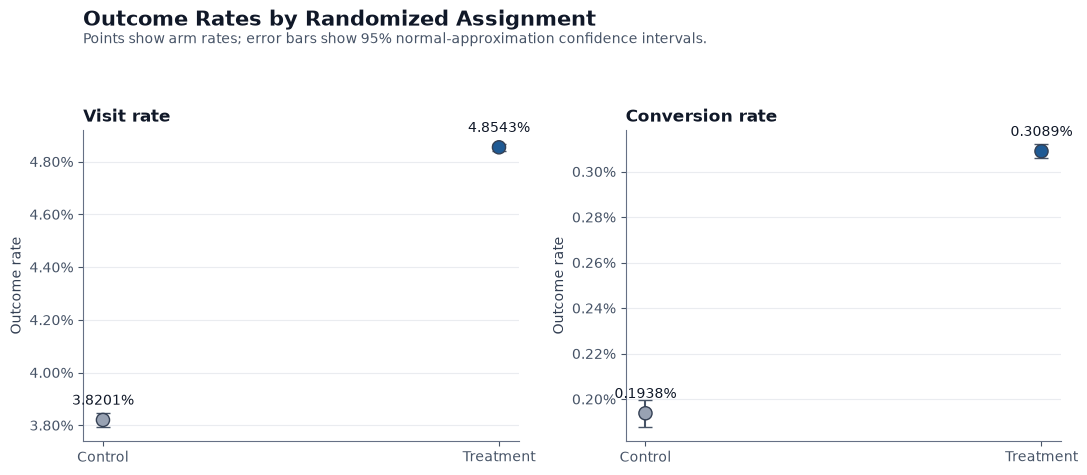

Saved: /Users/ever/Library/CloudStorage/OneDrive2-ColumbiaUniversityIrvingMedicalCenter/adlift项目/reports/figures/phase2/arm_rates.png


In [11]:
rate_plot_rows = []
for _, row in effect_results.iterrows():
    for arm in ["Control", "Treatment"]:
        rate = row["control_rate"] if arm == "Control" else row["treatment_rate"]
        n = row["control_n"] if arm == "Control" else row["treatment_n"]
        standard_error = np.sqrt(rate * (1 - rate) / n)
        rate_plot_rows.append(
            {
                "outcome": row["outcome"],
                "arm": arm,
                "rate": rate,
                "ci_lower": max(0, rate - Z_CRITICAL * standard_error),
                "ci_upper": min(1, rate + Z_CRITICAL * standard_error),
            }
        )

rate_plot_data = pd.DataFrame(rate_plot_rows)
figure, axes = plt.subplots(1, 2, figsize=(11, 4.8))

for axis, outcome in zip(axes, ["visit", "conversion"]):
    subset = rate_plot_data.loc[rate_plot_data["outcome"] == outcome].copy()
    x_positions = np.arange(len(subset))
    colors = [CONTROL_COLOR, TREATMENT_COLOR]
    lower_errors = subset["rate"] - subset["ci_lower"]
    upper_errors = subset["ci_upper"] - subset["rate"]

    axis.errorbar(
        x_positions,
        subset["rate"],
        yerr=np.vstack([lower_errors, upper_errors]),
        fmt="none",
        ecolor=REFERENCE_COLOR,
        capsize=5,
        linewidth=1.5,
        zorder=2,
    )
    axis.scatter(x_positions, subset["rate"], s=90, c=colors, edgecolor="#344054", zorder=3)

    for x_position, rate in zip(x_positions, subset["rate"]):
        axis.annotate(
            f"{rate:.4%}",
            (x_position, rate),
            xytext=(0, 11),
            textcoords="offset points",
            ha="center",
            fontsize=10,
        )

    axis.set_xticks(x_positions, subset["arm"])
    axis.set_ylabel("Outcome rate")
    axis.set_title(f"{outcome.title()} rate", loc="left", fontweight="bold")
    axis.grid(axis="y", color="#EAECF0", linewidth=0.8)
    axis.spines[["top", "right"]].set_visible(False)
    axis.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.2%}"))

figure.suptitle("Outcome Rates by Randomized Assignment", x=0.08, ha="left", fontsize=15, fontweight="bold")
figure.text(0.08, 0.91, "Points show arm rates; error bars show 95% normal-approximation confidence intervals.", color="#475467")
figure.tight_layout(rect=[0, 0, 1, 0.88])

arm_rates_path = FIGURE_DIRECTORY / "arm_rates.png"
figure.savefig(arm_rates_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {arm_rates_path}")

### Figure 2 — Absolute lift

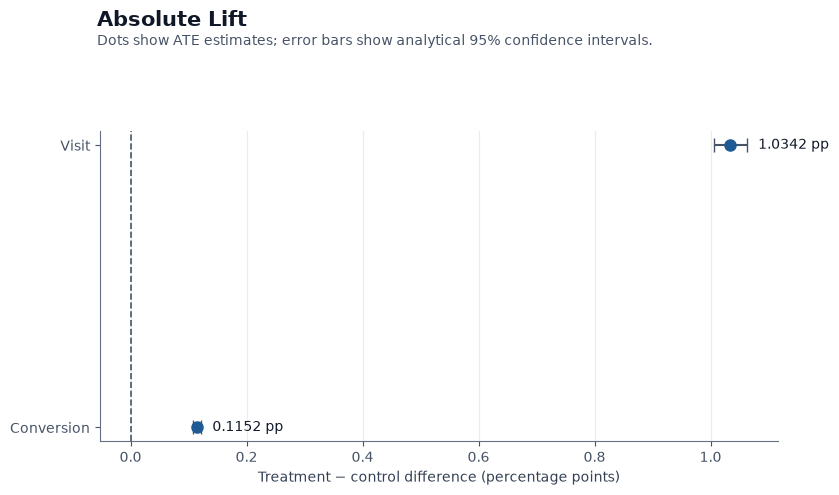

Saved: /Users/ever/Library/CloudStorage/OneDrive2-ColumbiaUniversityIrvingMedicalCenter/adlift项目/reports/figures/phase2/absolute_lift.png


In [12]:
absolute_plot = effect_results.sort_values("absolute_lift").copy()
figure, axis = plt.subplots(figsize=(8.5, 5.0))
y_positions = np.arange(len(absolute_plot))

axis.errorbar(
    absolute_plot["absolute_lift"] * 100,
    y_positions,
    xerr=np.vstack(
        [
            (absolute_plot["absolute_lift"] - absolute_plot["absolute_ci_lower"]) * 100,
            (absolute_plot["absolute_ci_upper"] - absolute_plot["absolute_lift"]) * 100,
        ]
    ),
    fmt="o",
    color=TREATMENT_COLOR,
    ecolor=REFERENCE_COLOR,
    capsize=5,
    markersize=8,
)
axis.axvline(0, color=REFERENCE_COLOR, linestyle="--", linewidth=1.2)
axis.set_yticks(y_positions, absolute_plot["outcome"].str.title())
axis.set_xlabel("Treatment − control difference (percentage points)")
axis.grid(axis="x", color="#EAECF0", linewidth=0.8)
axis.spines[["top", "right"]].set_visible(False)

for _, row in absolute_plot.iterrows():
    y_position = absolute_plot.index.get_loc(row.name)
    axis.annotate(
        f"{row['absolute_lift'] * 100:.4f} pp",
        (row["absolute_ci_upper"] * 100, y_position),
        xytext=(8, 0),
        textcoords="offset points",
        va="center",
    )

figure.suptitle("Absolute Lift", x=0.12, y=0.98, ha="left", fontsize=15, fontweight="bold")
figure.text(0.12, 0.91, "Dots show ATE estimates; error bars show analytical 95% confidence intervals.", color="#475467")
figure.tight_layout(rect=[0, 0, 1, 0.84])
absolute_lift_path = FIGURE_DIRECTORY / "absolute_lift.png"
figure.savefig(absolute_lift_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {absolute_lift_path}")

### Figure 3 — Relative lift

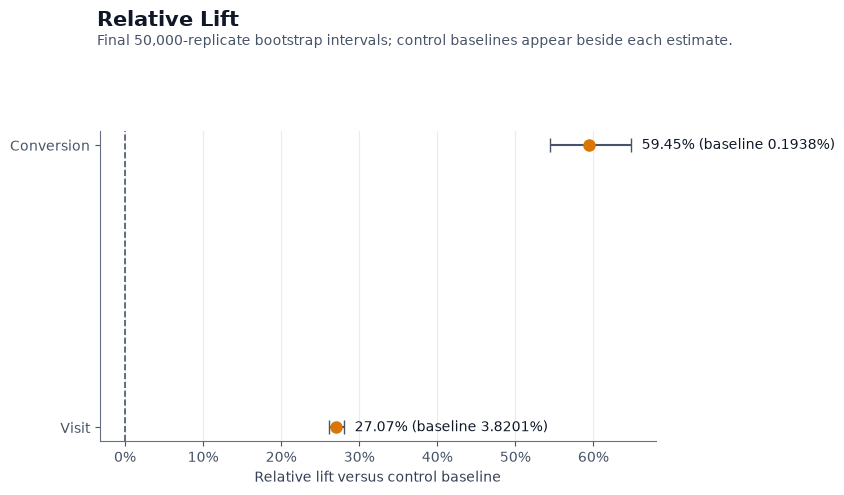

Saved: /Users/ever/Library/CloudStorage/OneDrive2-ColumbiaUniversityIrvingMedicalCenter/adlift项目/reports/figures/phase2/relative_lift.png


In [13]:
relative_bootstrap = final_bootstrap_intervals.loc[
    final_bootstrap_intervals["measure"] == "relative_lift",
    ["outcome", "bootstrap_ci_lower", "bootstrap_ci_upper"],
]
relative_plot = effect_results.merge(relative_bootstrap, on="outcome", validate="one_to_one")
relative_plot = relative_plot.sort_values("relative_lift")

figure, axis = plt.subplots(figsize=(8.5, 5.0))
y_positions = np.arange(len(relative_plot))
axis.errorbar(
    relative_plot["relative_lift"] * 100,
    y_positions,
    xerr=np.vstack(
        [
            (relative_plot["relative_lift"] - relative_plot["bootstrap_ci_lower"]) * 100,
            (relative_plot["bootstrap_ci_upper"] - relative_plot["relative_lift"]) * 100,
        ]
    ),
    fmt="o",
    color=SECONDARY_COLOR,
    ecolor=REFERENCE_COLOR,
    capsize=5,
    markersize=8,
)
axis.axvline(0, color=REFERENCE_COLOR, linestyle="--", linewidth=1.2)
axis.set_yticks(y_positions, relative_plot["outcome"].str.title())
axis.set_xlabel("Relative lift versus control baseline")
axis.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0f}%"))
axis.grid(axis="x", color="#EAECF0", linewidth=0.8)
axis.spines[["top", "right"]].set_visible(False)

for y_position, (_, row) in enumerate(relative_plot.iterrows()):
    axis.annotate(
        f"{row['relative_lift']:.2%} (baseline {row['control_rate']:.4%})",
        (row["bootstrap_ci_upper"] * 100, y_position),
        xytext=(8, 0),
        textcoords="offset points",
        va="center",
    )

figure.suptitle("Relative Lift", x=0.12, y=0.98, ha="left", fontsize=15, fontweight="bold")
figure.text(0.12, 0.91, f"Final {final_replicates:,}-replicate bootstrap intervals; control baselines appear beside each estimate.", color="#475467")
figure.tight_layout(rect=[0, 0, 1, 0.84])
relative_lift_path = FIGURE_DIRECTORY / "relative_lift.png"
figure.savefig(relative_lift_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {relative_lift_path}")

### Figure 4 — Incremental outcome scale

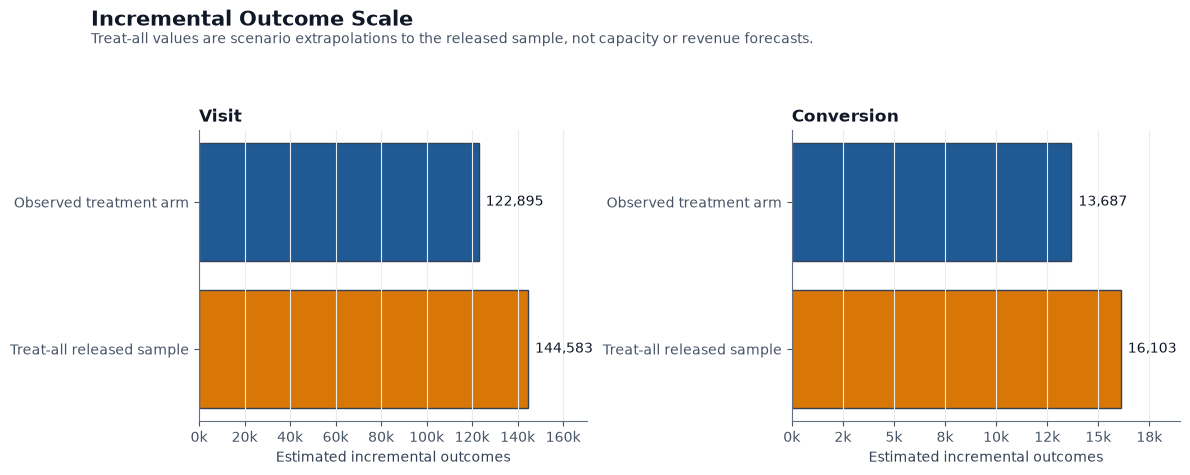

Saved: /Users/ever/Library/CloudStorage/OneDrive2-ColumbiaUniversityIrvingMedicalCenter/adlift项目/reports/figures/phase2/incremental_outcomes.png


In [14]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4.8))

for axis, (_, row) in zip(axes, effect_results.iterrows()):
    labels = ["Observed treatment arm", "Treat-all released sample"]
    values = [row["incremental_treated"], row["incremental_all"]]
    bars = axis.barh(labels, values, color=[TREATMENT_COLOR, SECONDARY_COLOR], edgecolor="#344054")
    axis.set_title(row["outcome"].title(), loc="left", fontweight="bold")
    axis.set_xlabel("Estimated incremental outcomes")
    axis.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda value, _: f"{value / 1_000:.0f}k")
    )
    axis.grid(axis="x", color="#EAECF0", linewidth=0.8)
    axis.spines[["top", "right"]].set_visible(False)
    axis.invert_yaxis()
    axis.bar_label(bars, labels=[f"{value:,.0f}" for value in values], padding=5)
    axis.set_xlim(0, max(values) * 1.18)

figure.suptitle("Incremental Outcome Scale", x=0.08, ha="left", fontsize=15, fontweight="bold")
figure.text(0.08, 0.91, "Treat-all values are scenario extrapolations to the released sample, not capacity or revenue forecasts.", color="#475467")
figure.tight_layout(rect=[0, 0, 1, 0.88])

incremental_path = FIGURE_DIRECTORY / "incremental_outcomes.png"
figure.savefig(incremental_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {incremental_path}")

### Figure 5 — Experiment delivery stages

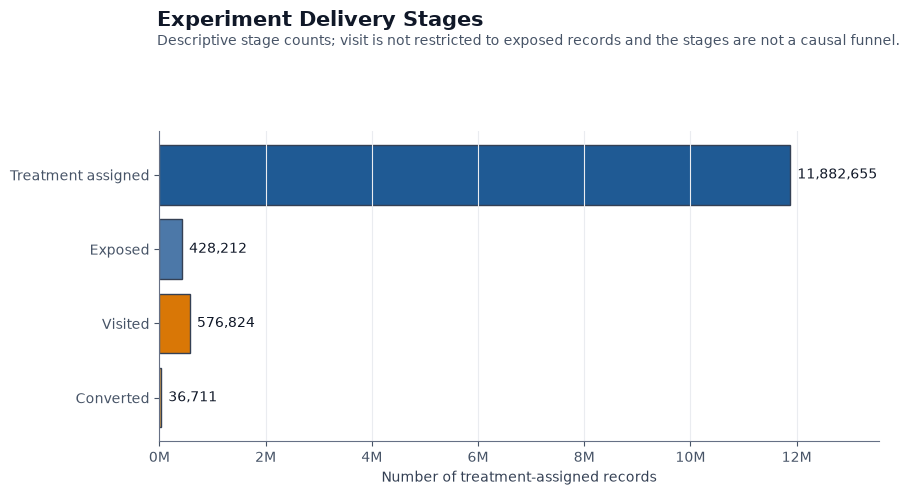

Saved: /Users/ever/Library/CloudStorage/OneDrive2-ColumbiaUniversityIrvingMedicalCenter/adlift项目/reports/figures/phase2/experiment_delivery_funnel.png


In [15]:
delivery_counts = pd.DataFrame(
    {
        "stage": ["Treatment assigned", "Exposed", "Visited", "Converted"],
        "count": [
            int(treatment_row["sample_size"]),
            int(treatment_row["exposure_positive"]),
            int(treatment_row["visit_positive"]),
            int(treatment_row["conversion_positive"]),
        ],
    }
)

figure, axis = plt.subplots(figsize=(9, 5))
bars = axis.barh(
    delivery_counts["stage"],
    delivery_counts["count"],
    color=[TREATMENT_COLOR, "#4C78A8", SECONDARY_COLOR, "#E9A23B"],
    edgecolor="#344054",
)
axis.invert_yaxis()
axis.set_xlabel("Number of treatment-assigned records")
axis.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value / 1_000_000:.0f}M")
)
axis.grid(axis="x", color="#EAECF0", linewidth=0.8)
axis.spines[["top", "right"]].set_visible(False)
axis.bar_label(bars, labels=[f"{value:,.0f}" for value in delivery_counts["count"]], padding=5)
axis.set_xlim(0, delivery_counts["count"].max() * 1.14)
figure.suptitle("Experiment Delivery Stages", x=0.18, y=0.98, ha="left", fontsize=15, fontweight="bold")
figure.text(0.18, 0.91, "Descriptive stage counts; visit is not restricted to exposed records and the stages are not a causal funnel.", color="#475467")
figure.tight_layout(rect=[0, 0, 1, 0.84])

delivery_funnel_path = FIGURE_DIRECTORY / "experiment_delivery_funnel.png"
figure.savefig(delivery_funnel_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {delivery_funnel_path}")

## 11. Final Results Table

In [16]:
absolute_bootstrap = final_bootstrap_intervals.loc[
    final_bootstrap_intervals["measure"] == "absolute_lift",
    ["outcome", "bootstrap_ci_lower", "bootstrap_ci_upper"],
].rename(
    columns={
        "bootstrap_ci_lower": "absolute_bootstrap_ci_lower",
        "bootstrap_ci_upper": "absolute_bootstrap_ci_upper",
    }
)

relative_bootstrap = final_bootstrap_intervals.loc[
    final_bootstrap_intervals["measure"] == "relative_lift",
    ["outcome", "bootstrap_ci_lower", "bootstrap_ci_upper"],
].rename(
    columns={
        "bootstrap_ci_lower": "relative_bootstrap_ci_lower",
        "bootstrap_ci_upper": "relative_bootstrap_ci_upper",
    }
)

final_results = (
    effect_results.merge(absolute_bootstrap, on="outcome", validate="one_to_one")
    .merge(relative_bootstrap, on="outcome", validate="one_to_one")
    .merge(hypothesis_tests, on="outcome", validate="one_to_one")
)

final_columns = [
    "outcome",
    "control_n",
    "treatment_n",
    "control_positive",
    "treatment_positive",
    "control_rate",
    "treatment_rate",
    "absolute_lift",
    "absolute_ci_lower",
    "absolute_ci_upper",
    "absolute_bootstrap_ci_lower",
    "absolute_bootstrap_ci_upper",
    "relative_lift",
    "relative_ci_lower",
    "relative_ci_upper",
    "relative_bootstrap_ci_lower",
    "relative_bootstrap_ci_upper",
    "incremental_treated",
    "incremental_all",
    "z_statistic",
    "raw_p_value",
    "raw_log10_p_value",
    "raw_p_value_display",
    "holm_adjusted_p_value",
    "holm_p_value_display",
    "reject_at_0_05",
]
final_results = final_results[final_columns]

results_table_path = TABLE_DIRECTORY / "phase2_effect_summary.csv"
exposure_table_path = TABLE_DIRECTORY / "phase2_exposure_appendix.csv"
bootstrap_qa_path = TABLE_DIRECTORY / "phase2_bootstrap_qa.csv"

final_results.to_csv(results_table_path, index=False)
exposure_delivery.to_csv(exposure_table_path, index=False)
interval_agreement.to_csv(bootstrap_qa_path, index=False)

display(
    final_results.style.format(
        {
            "control_n": "{:,.0f}",
            "treatment_n": "{:,.0f}",
            "control_positive": "{:,.0f}",
            "treatment_positive": "{:,.0f}",
            "control_rate": "{:.4%}",
            "treatment_rate": "{:.4%}",
            "absolute_lift": "{:.4%}",
            "absolute_ci_lower": "{:.4%}",
            "absolute_ci_upper": "{:.4%}",
            "absolute_bootstrap_ci_lower": "{:.4%}",
            "absolute_bootstrap_ci_upper": "{:.4%}",
            "relative_lift": "{:.2%}",
            "relative_ci_lower": "{:.2%}",
            "relative_ci_upper": "{:.2%}",
            "relative_bootstrap_ci_lower": "{:.2%}",
            "relative_bootstrap_ci_upper": "{:.2%}",
            "incremental_treated": "{:,.0f}",
            "incremental_all": "{:,.0f}",
            "z_statistic": "{:.4f}",
            "raw_p_value": "{:.3e}",
            "holm_adjusted_p_value": "{:.3e}",
        }
    )
)

print(f"Saved: {results_table_path}")
print(f"Saved: {exposure_table_path}")
print(f"Saved: {bootstrap_qa_path}")

,outcome,control_n,treatment_n,control_positive,treatment_positive,control_rate,treatment_rate,absolute_lift,absolute_ci_lower,absolute_ci_upper,absolute_bootstrap_ci_lower,absolute_bootstrap_ci_upper,relative_lift,relative_ci_lower,relative_ci_upper,relative_bootstrap_ci_lower,relative_bootstrap_ci_upper,incremental_treated,incremental_all,z_statistic,raw_p_value,raw_log10_p_value,raw_p_value_display,holm_adjusted_p_value,holm_p_value_display,reject_at_0_05
0,visit,"2,096,937","11,882,655","80,105","576,824",3.8201%,4.8543%,1.0342%,1.0056%,1.0629%,1.0054%,1.0627%,27.07%,26.16%,28.00%,26.15%,27.99%,"122,895","144,583",65.2474,0.000e+00,-926.357836,<1e-926,0.000e+00,<1e-926,True
1,conversion,"2,096,937","11,882,655","4,063","36,711",0.1938%,0.3089%,0.1152%,0.1085%,0.1219%,0.1084%,0.1219%,59.45%,54.37%,64.70%,54.40%,64.76%,"13,687","16,103",28.5165,7.308e-179,-178.136186,7.308e-179,7.308e-179,7.308e-179,True


Saved: /Users/ever/Library/CloudStorage/OneDrive2-ColumbiaUniversityIrvingMedicalCenter/adlift项目/reports/tables/phase2_effect_summary.csv
Saved: /Users/ever/Library/CloudStorage/OneDrive2-ColumbiaUniversityIrvingMedicalCenter/adlift项目/reports/tables/phase2_exposure_appendix.csv
Saved: /Users/ever/Library/CloudStorage/OneDrive2-ColumbiaUniversityIrvingMedicalCenter/adlift项目/reports/tables/phase2_bootstrap_qa.csv


## 12. Joint Business Interpretation

In [17]:
visit_result = final_results.loc[final_results["outcome"] == "visit"].iloc[0]
conversion_result = final_results.loc[final_results["outcome"] == "conversion"].iloc[0]

visit_absolute_width = visit_result["absolute_ci_upper"] - visit_result["absolute_ci_lower"]
conversion_absolute_width = (
    conversion_result["absolute_ci_upper"] - conversion_result["absolute_ci_lower"]
)

display(
    Markdown(
        f"""
### Answers to the Phase 2 business questions

1. **Did enabling advertising increase visits?**  
   Yes. The visit rate increased from **{visit_result['control_rate']:.4%}** to **{visit_result['treatment_rate']:.4%}**. The absolute lift is **{visit_result['absolute_lift']:.4%}** (95% analytical CI **[{visit_result['absolute_ci_lower']:.4%}, {visit_result['absolute_ci_upper']:.4%}]**), and the relative lift is **{visit_result['relative_lift']:.2%}**.

2. **Did enabling advertising increase conversions?**  
   Yes. The conversion rate increased from **{conversion_result['control_rate']:.4%}** to **{conversion_result['treatment_rate']:.4%}**. The absolute lift is **{conversion_result['absolute_lift']:.4%}** (95% analytical CI **[{conversion_result['absolute_ci_lower']:.4%}, {conversion_result['absolute_ci_upper']:.4%}]**), and the relative lift is **{conversion_result['relative_lift']:.2%}**.

3. **What do the absolute and relative effects mean together?**  
   Visit improved by **{visit_result['absolute_lift'] * 100:.4f} percentage points** or **{visit_result['relative_lift']:.2%}** relative to its control baseline. Conversion improved by **{conversion_result['absolute_lift'] * 100:.4f} percentage points** or **{conversion_result['relative_lift']:.2%}** relative to its much lower baseline. Relative effects must therefore be read beside baseline rates.

4. **How many incremental outcomes does this represent?**  
   Within the observed treatment arm, the estimates imply approximately **{visit_result['incremental_treated']:,.0f} incremental visits** and **{conversion_result['incremental_treated']:,.0f} incremental conversions**. Treating the entire released population would imply approximately **{visit_result['incremental_all']:,.0f} visits** and **{conversion_result['incremental_all']:,.0f} conversions**, but these are scenario extrapolations rather than delivery-capacity forecasts.

5. **Is conversion less precise because it is rare?**  
   Yes in relative terms and event information: control conversion is only **{conversion_result['control_rate']:.4%}**, compared with a **{visit_result['control_rate']:.4%}** control visit rate. Its relative-lift interval is wider, reflecting fewer positive events. Absolute interval widths are not directly comparable without considering the very different metric scales.

6. **Does visit lift translate proportionally into conversion lift?**  
   No. The estimated relative conversion lift (**{conversion_result['relative_lift']:.2%}**) is materially larger than the relative visit lift (**{visit_result['relative_lift']:.2%}**). This aggregate experiment does not identify why the two stages respond differently, but it shows that a simple one-to-one proportional translation is not supported.

7. **What remains unknown?**  
   The released data do not include campaign identity, timestamps, cost, revenue, auction prices, or advertiser details. The analysis therefore cannot estimate ROI, profit, campaign-level effects, seasonality, long-term effects, or operational capacity for treating everyone.

### Overall conclusion

Randomized assignment to the advertising strategy increased both visits and conversions in the released sample. The result establishes positive average incrementality and supports proceeding to Phase 3 heterogeneous-uplift modeling. It does **not** imply that every user benefits or that every user should be targeted.
"""
    )
)


### Answers to the Phase 2 business questions

1. **Did enabling advertising increase visits?**  
   Yes. The visit rate increased from **3.8201%** to **4.8543%**. The absolute lift is **1.0342%** (95% analytical CI **[1.0056%, 1.0629%]**), and the relative lift is **27.07%**.

2. **Did enabling advertising increase conversions?**  
   Yes. The conversion rate increased from **0.1938%** to **0.3089%**. The absolute lift is **0.1152%** (95% analytical CI **[0.1085%, 0.1219%]**), and the relative lift is **59.45%**.

3. **What do the absolute and relative effects mean together?**  
   Visit improved by **1.0342 percentage points** or **27.07%** relative to its control baseline. Conversion improved by **0.1152 percentage points** or **59.45%** relative to its much lower baseline. Relative effects must therefore be read beside baseline rates.

4. **How many incremental outcomes does this represent?**  
   Within the observed treatment arm, the estimates imply approximately **122,895 incremental visits** and **13,687 incremental conversions**. Treating the entire released population would imply approximately **144,583 visits** and **16,103 conversions**, but these are scenario extrapolations rather than delivery-capacity forecasts.

5. **Is conversion less precise because it is rare?**  
   Yes in relative terms and event information: control conversion is only **0.1938%**, compared with a **3.8201%** control visit rate. Its relative-lift interval is wider, reflecting fewer positive events. Absolute interval widths are not directly comparable without considering the very different metric scales.

6. **Does visit lift translate proportionally into conversion lift?**  
   No. The estimated relative conversion lift (**59.45%**) is materially larger than the relative visit lift (**27.07%**). This aggregate experiment does not identify why the two stages respond differently, but it shows that a simple one-to-one proportional translation is not supported.

7. **What remains unknown?**  
   The released data do not include campaign identity, timestamps, cost, revenue, auction prices, or advertiser details. The analysis therefore cannot estimate ROI, profit, campaign-level effects, seasonality, long-term effects, or operational capacity for treating everyone.

### Overall conclusion

Randomized assignment to the advertising strategy increased both visits and conversions in the released sample. The result establishes positive average incrementality and supports proceeding to Phase 3 heterogeneous-uplift modeling. It does **not** imply that every user benefits or that every user should be targeted.


## 13. Limitations and Handoff

- The public benchmark is anonymized and subsampled. Report these estimates as effects in the released experimental sample, not as the original incrementality of a specific advertiser or campaign.
- The dataset has no user ID, event ID, or timestamp. Exact duplicate-looking rows cannot be proven to be duplicate users or events and were retained according to the Phase 1 decision.
- Exposure delivery is incomplete and selected through the advertising auction. Exposed-versus-unexposed differences are observational.
- The optional Wald ratio requires stronger instrumental-variable assumptions than the main ITT analysis.
- No campaign, time, cost, or revenue fields are available, so profitability and external validity across campaigns or seasons remain unknown.
- A positive average effect motivates, but does not guarantee success of, Phase 3 heterogeneous treatment-effect modeling.

## 14. Reproducibility Checks and Close

In [18]:
required_figure_paths = [
    arm_rates_path,
    absolute_lift_path,
    relative_lift_path,
    incremental_path,
    delivery_funnel_path,
]
required_table_paths = [
    results_table_path,
    exposure_table_path,
    bootstrap_qa_path,
]

assert all(path.exists() and path.stat().st_size > 0 for path in required_figure_paths)
assert all(path.exists() and path.stat().st_size > 0 for path in required_table_paths)
assert len(final_results) == 2
assert final_stability["stability_pass"].all()
assert interval_agreement["agreement_pass"].all()
assert hypothesis_tests["reject_at_0_05"].all()

connection.close()

print(f"Final bootstrap replicates per outcome: {final_replicates:,}")
print("All required figures and tables were created.")
print("All Phase 2 analytical and reproducibility checks passed.")
print("Database connection closed.")

Final bootstrap replicates per outcome: 50,000
All required figures and tables were created.
All Phase 2 analytical and reproducibility checks passed.
Database connection closed.
